# 4. Two-island model

Formålet med denne notebook er at bygge en two-island model og bruge den til inferens. Modellen beskriver to populationer, hvor linjer kan migrere mellem øerne, men der er ingen fælles forfader-population (migration alene opretholder forbindelsen), der er en konstant rate. Dette er den simpleste model som jeg laver først, før jeg går videre til isolation with migration (IM) modellen i notebook 05.

I artiklen af Sørensen et al. 2023 dokumenteres admixture mellem eastern yellow baboons og Kinda baboons. De er tæt forbundet og der er geneflow mellem dem. Two island modellen kan give en konstant migrationsestimat. 

Jeg kommer i denne notebook ind på følgende:

1. Byg two-island model
2. Teoretiske egenskaber
3. Joint-probability graf og SFS inference med SVGD
4. Simuler testdata med msprime
5. Validering: genfind sande parametre fra msprime-simulering
6. Anvende modellen på bavian-data (Yellow baboon vs. Kinda baboon) fra notebook 03
7. Samlet resultater

Indlæs data fra notebook 03

In [ ]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"   # Brug kun GPU 0 (eller fjern linjen på CPU-maskiner)
os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count=1"
# phasic importeres først for at sætte JAX-backend korrekt

from phasic import (
    Graph, with_ipv, GaussPrior, HalfCauchyPrior,
    Adam, ExpStepSize, ExpRegularization,
    StateIndexer, Property, set_log_level,
)
set_log_level("WARNING")

import numpy as np
import jax.numpy as jnp
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from functools import partial
from itertools import combinations_with_replacement
import msprime

from vscodenb import set_vscode_theme
all_pairs = partial(combinations_with_replacement, r=2)
np.random.seed(42)
sns.set_palette("tab10")


MUT_RATE = 0.9e-8
GEN_TIME = 11
OUT_DIR = Path("output")
OUT_DIR.mkdir(exist_ok=True)


print("Imports OK")

## Definer staterummet

Jeg bruger *StateIndexer* og *Property* til at definere en struktureret statevektor:

- $pop1$: antal efterkommere fra population 1
- $pop2$: antal efterkommere fra population 2  
- $in_{pop}$: hvilken population linjen befinder sig i (1 eller 2)

En state er f.eks. "en linje med 2 efterkommere fra pop1 og 0 fra pop2, der nu befinder sig i population 1".

In [2]:
nr_samples = 2

indexer = StateIndexer(
    descendants=[
    Property('pop1', min_value=0, max_value=nr_samples),
    Property('pop2', min_value=0, max_value=nr_samples),
    Property('in_pop', min_value=1, max_value=2),
])

# Initial state: alle linjer fra pop1, befinder sig i pop1
initial = [0] * indexer.state_length
initial[indexer.descendants.props_to_index(pop1=1, pop2=0, in_pop=1)] = nr_samples

print(f"State vector length: {indexer.state_length}")
print(f"Initial state: {initial}")

State vector length: 18
Initial state: [0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


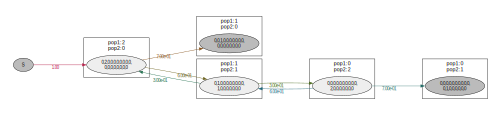

In [3]:
@with_ipv(initial)
def two_island(state):
    transitions = []

    if state[indexer.descendants.indices()].sum() <= 1:
        return transitions
    
    for i in range(indexer.descendants.state_length):
        if state[i] == 0: continue
        props_i = indexer.descendants.index_to_props(i)

        for j in range(i, indexer.descendants.state_length):
            if state[j] == 0: continue
            props_j = indexer.descendants.index_to_props(j)
            
            if props_j.in_pop != props_i.in_pop:
                continue

            same = int(i == j)
            if same and state[i] < 2:
                continue
            if not same and (state[i] < 1 or state[j] < 1):
                continue 

            child = state.copy()
            child[i] -= 1
            child[j] -= 1
            des_pop1 = props_i.pop1 + props_j.pop1
            des_pop2 = props_i.pop2 + props_j.pop2
            if des_pop1 <= nr_samples and des_pop2 <= nr_samples:
                k = indexer.descendants.props_to_index(
                    pop1=des_pop1, 
                    pop2=des_pop2, 
                    in_pop=props_i.in_pop
                    )
                child[k] += 1
                transitions.append([child, [state[i]*(state[j]-same)/(1+same), 0]])

        if state[i] > 0:
            child = state.copy()
            other_pop = 2 if props_i.in_pop == 1 else 1
            child = state.copy()
            child[i] -= 1
            k = indexer.descendants.props_to_index(
                pop1=props_i.pop1, 
                pop2=props_i.pop2, 
                in_pop=other_pop
                )
            child[k] += 1

            transitions.append([child, [0, state[i]]])

    return transitions

graph = Graph(two_island)   

true_theta = [0.7, 0.3]
graph.update_weights(true_theta)

def label(state):
    nr_pop1 = sum([state[i] * bool(indexer.index_to_props(i).descendants.in_pop == 1) for i in indexer])
    nr_pop2 = sum([state[i] * bool(indexer.index_to_props(i).descendants.in_pop == 2) for i in indexer])
    return f"pop1: {nr_pop1}\npop2: {nr_pop2}"

graph.plot(rankdir='LR', nodesep=0.3, ranksep=2,
                      wrap=10, 
                    #   label_fmt=False, 
                      by_state=label)

## Effekt af migration på coalescent-processen

Undersøger hvordan migrationsraten påvirker:

1. Den forventede TMRCA
2. Fordelingen (PDF) af TMRCA

Høj migration $\rightarrow$ populationerne opfører sig næsten som en stor population $\rightarrow$ kortere coalescent-tider og mere jævn SFS. 
Lav migration $\rightarrow$ populationerne er mere isolerede $\rightarrow$ længere og mere varierende coalescent-tider.

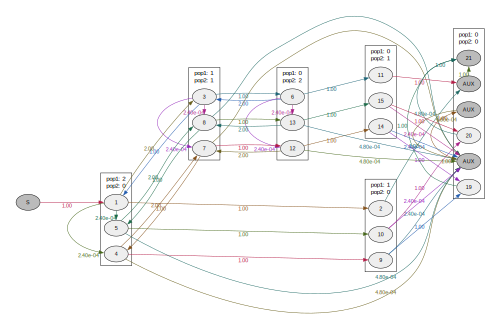

In [4]:
mutation_rate = 1.2e-4
joint_prob_graph = graph.joint_prob_graph(indexer, 
                                          reward_only=['pop1', 'pop2'],
                                          reward_limit=1,
                                          tot_reward_limit=1, 
                                          mutation_rate=mutation_rate)

joint_prob_graph.plot(rankdir='LR', nodesep=0.3, ranksep=2,
                      wrap=10, label_fmt=False, by_state=label)

In [5]:
joint_prob_table = joint_prob_graph.joint_prob_table()
joint_prob_table

,pop1_0,pop1_1,pop1_2,pop2_0,pop2_1,pop2_2,prob
t_vertex_index,,,,,,,
18,0,0,0,0,0,0,0.999041
19,0,1,0,0,0,0,0.000479
20,0,0,0,1,0,0,0.000479


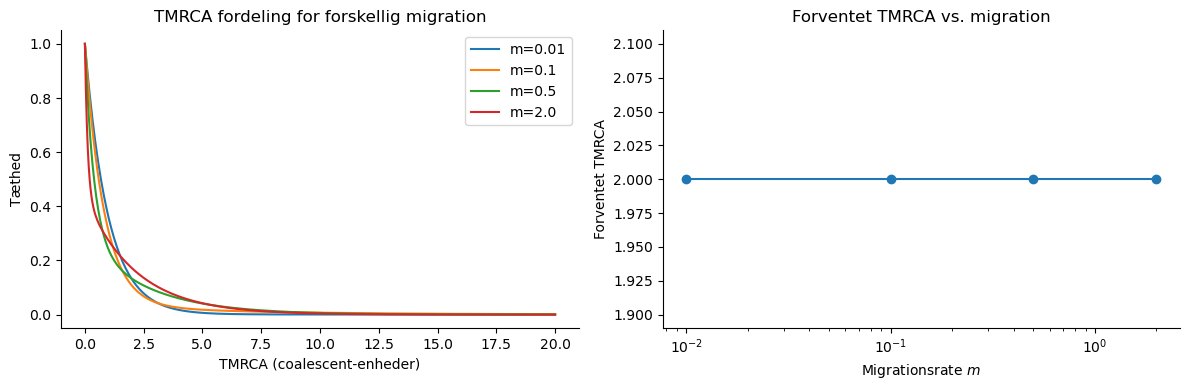

m=0.01: E[TMRCA] = 2.000
m=0.10: E[TMRCA] = 2.000
m=0.50: E[TMRCA] = 2.000
m=2.00: E[TMRCA] = 2.000


In [6]:
# Undersøg effekt af migration
N = 1  # N_e i coalescent-enheder (normaliseret)
migration_rates = [0.01, 0.1, 0.5, 2.0]
t_range = np.linspace(0, 20, 500)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

expectations = []
for m in migration_rates:
    graph.update_weights([1/N, m])
    pdfs = graph.pdf(t_range)
    e_tmrca = graph.expectation()
    expectations.append(e_tmrca)
    axes[0].plot(t_range, pdfs, label=f'm={m}')

axes[0].set_xlabel('TMRCA (coalescent-enheder)')
axes[0].set_ylabel('Tæthed')
axes[0].set_title('TMRCA fordeling for forskellig migration')
axes[0].legend()
sns.despine(ax=axes[0])

axes[1].plot(migration_rates, expectations, 'o-', color='C0')
axes[1].set_xlabel('Migrationsrate $m$')
axes[1].set_ylabel('Forventet TMRCA')
axes[1].set_title('Forventet TMRCA vs. migration')
axes[1].set_xscale('log')
sns.despine(ax=axes[1])

plt.tight_layout()
plt.show()

for m, e in zip(migration_rates, expectations):
    print(f"m={m:.2f}: E[TMRCA] = {e:.3f}")

## SVGD-inferens: Estimer N og m

Nu estimerer jeg begge parametre simultant: coalescent-rate ($\theta_c = 1/N$) og migrationsrate ($\theta_m = m$).

Jeg genererer testdata fra kendte parametre og ser om SVGD kan genfinde dem.

In [7]:
# Sæt sande parametre og generer data
true_theta = [0.7, 0.9]  # [coalescent-rate, migrationsrate]
graph.update_weights(true_theta)

nr_observations = 1000
observed_data = graph.sample(nr_observations)

print(f"Sand theta = {true_theta}")
print(f"Svarende til N = {1/true_theta[0]:.1f}, m = {true_theta[1]:.2f}")
print(f"Forventet TMRCA: {graph.expectation():.3f}")
print(f"Median observeret TMRCA: {np.median(observed_data):.3f}")

Sand theta = [0.7, 0.9]
Svarende til N = 1.4, m = 0.90
Forventet TMRCA: 2.857
Median observeret TMRCA: 1.782


In [8]:
# Kør SVGD med to parametre
svgd = graph.svgd(
    observed_data,
    prior=[
        HalfCauchyPrior(ci=2.0, prob=0.9),   # Prior for coalescent-rate
        HalfCauchyPrior(ci=1.0, prob=0.9),   # Prior for migrationsrate
    ],
    optimizer=Adam(learning_rate=0.05),
    n_iterations=300,
    n_particles=40,
)
svgd.summary()

W0430 17:58:52.148091  643567 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


Parameter  Fixed      MAP        Mean       SD         HPD 95% lo   HPD 95% hi  
0          No         0.7180     0.5750     0.1751     0.3598       0.7200      
1          No         0.8478     0.5153     0.4248     0.0000       0.9320      

Particles: 40, Iterations: 300


In [9]:
# Sæt sande parametre og simuler data
true_theta = [0.7, 0.9] # coalescence-rate, migrationrate
graph.update_weights(true_theta)
observations = graph.sample(1000)

print(f"Two-island model: {graph.param_length()} parametre")
print(f"theta[0] = coalescence-rate = {true_theta[0]} (1/N_e)")
print(f"theta[1] = migrationrate = {true_theta[1]}")

# MoM estimering som udgangspunkt
mom= graph.method_of_moments(observations)

print(" MoM estimat (two-island model)")
print(f"Sand theta: {true_theta}")
print(f"MoM estimat: {mom.theta}")
print(f"Std. fejl: {mom.std}")
print(f"Konvergeret: {mom.success}")

Two-island model: 2 parametre
theta[0] = coalescence-rate = 0.7 (1/N_e)
theta[1] = migrationrate = 0.9


W0430 17:58:55.907682  643567 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0430 17:58:56.119516  643567 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


 MoM estimat (two-island model)
Sand theta: [0.7, 0.9]
MoM estimat: [0.67364689 0.64262299]
Std. fejl: [0.0239437 0.2064966]
Konvergeret: True


W0430 17:59:00.997912  643567 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


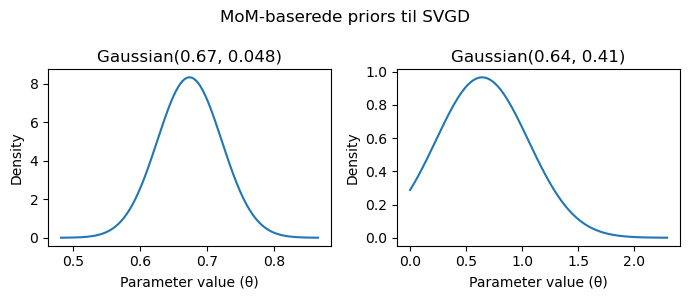

In [10]:
# SVGD med prior fra MoM-resultatet
# MoM giver automatisk et fornuftigt informeret prior
fig, axes = plt.subplots(1, len(mom.prior), figsize=(7, 3))
for i, prior in enumerate(mom.prior):
    prior.plot(return_ax=True, ax=axes[i])
plt.suptitle("MoM-baserede priors til SVGD")
plt.tight_layout()
plt.show()

In [11]:
# Kør SVGD inferens på two-island modellen med mom.prior
svgd = graph.svgd(
    observations,
    prior=mom.prior,
    learning_rate=ExpStepSize(first_step=0.05, last_step=0.005, tau=20.0),
    n_devices=1,
)

print("SVGD Resultat (two-island model)")
svgd.summary()

SVGD Resultat (two-island model)
Parameter  Fixed      MAP        Mean       SD         HPD 95% lo   HPD 95% hi  
0          No         0.6746     0.5961     0.1337     0.3538       0.6769      
1          No         0.7521     0.5582     0.3196     0.0000       0.7512      

Particles: 40, Iterations: 100


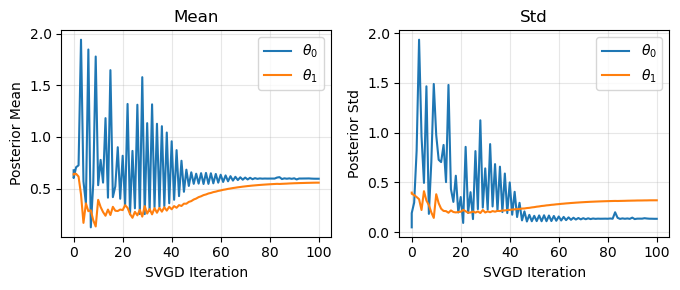

In [12]:
svgd.plot_convergence()

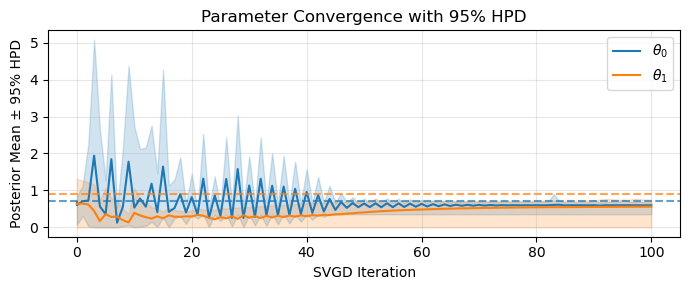

In [13]:
svgd.plot_ci(true_theta=true_theta)

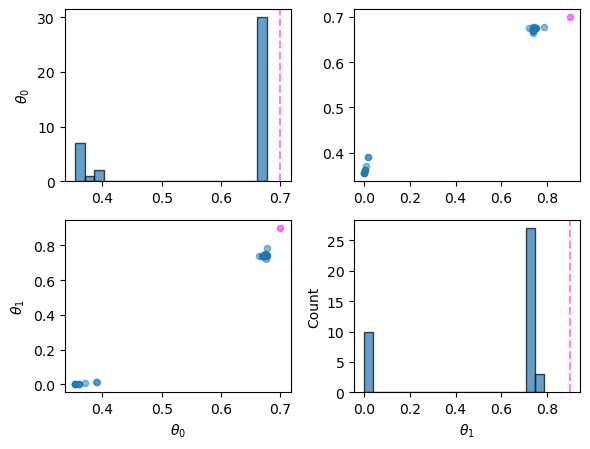

In [14]:
# Vis joint posterior (2D)
svgd.plot_pairwise(true_theta=true_theta)

## Bygger two-island modellen på en anden måde

Antal vertices i to-island grafen: 21
Antal parametre: 3
Two-island model: 21 state, 3 parametre


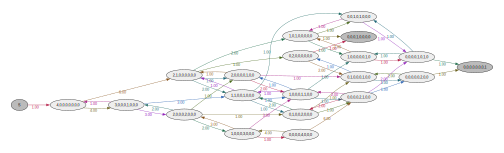

In [10]:
nr_samples = 4

indexer = StateIndexer(
    lineages=[
        Property("descendants", min_value=1, max_value=nr_samples),
        Property("in_pop",      min_value=1, max_value=2),
    ]
)

# Startstate: alle lineages er singletons i population 1
ipv = [0] * indexer.state_length
ipv[indexer.lineages.props_to_index(descendants=1, in_pop=1)] = nr_samples

@with_ipv(ipv)
def two_island(state, indexer=None):
    transitions = []
    if state.sum() <= 1:
        return transitions

    # Coalescence inden for hver population
    for i, j in all_pairs(indexer.lineages):
        pi = indexer.lineages.index_to_props(i)
        pj = indexer.lineages.index_to_props(j)
        if pi.in_pop != pj.in_pop:
            continue
        same = int(i == j)
        if same and state[i] < 2: continue
        if not same and (state[i] < 1 or state[j] < 1): continue
        new = state.copy()
        new[i] -= 1
        new[j] -= 1
        des = pi.descendants + pj.descendants
        if des > nr_samples: continue
        k = indexer.lineages.props_to_index(descendants=des, in_pop=pi.in_pop)
        new[k] += 1
        rate = state[i] * (state[j] - same) / (1 + same)
        coeff = [rate if pi.in_pop == 1 else 0,
                 rate if pi.in_pop == 2 else 0,
                 0]
        transitions.append([new, coeff])

    # Migration (symmetrisk rate m)
    for i in range(indexer.state_length):
        if state[i] == 0: continue
        pi = indexer.lineages.index_to_props(i)
        other = 2 if pi.in_pop == 1 else 1
        new = state.copy()
        new[i] -= 1
        k = indexer.lineages.props_to_index(descendants=pi.descendants, in_pop=other)
        new[k] += 1
        coeff = [0, 0, state[i]]  # migration-koefficient
        transitions.append([new, coeff])

    return transitions

graph_2i = Graph(two_island, indexer=indexer)
print(f"Antal vertices i to-island grafen: {graph_2i.vertices_length()}")
print(f"Antal parametre: {graph_2i.param_length()}")
print(f"Two-island model: {graph_2i.vertices_length()} state, {graph_2i.param_length()} parametre")

graph_2i.plot(nodesep=0.4, wrap=False)

## Teoretiske egenskaber

Med sande parametre $(N_1, N_2, m)=(1,2,0.5)$ beregner jeg forventet TMRCA og SFS under modellen.

In [11]:
# Sande parametre (i coalescent-enheder)
N1_true, N2_true, m_true = 1.0, 2.0, 0.5
true_theta = [1/N1_true, 1/N2_true, m_true]
graph_2i.update_weights(true_theta)

print(f"Forventet TMRCA: {graph_2i.expectation():.4f}")
print(f"Varians på TMRCA: {graph_2i.variance():.4f}")

Forventet TMRCA: 3.8232
Varians på TMRCA: 12.5316


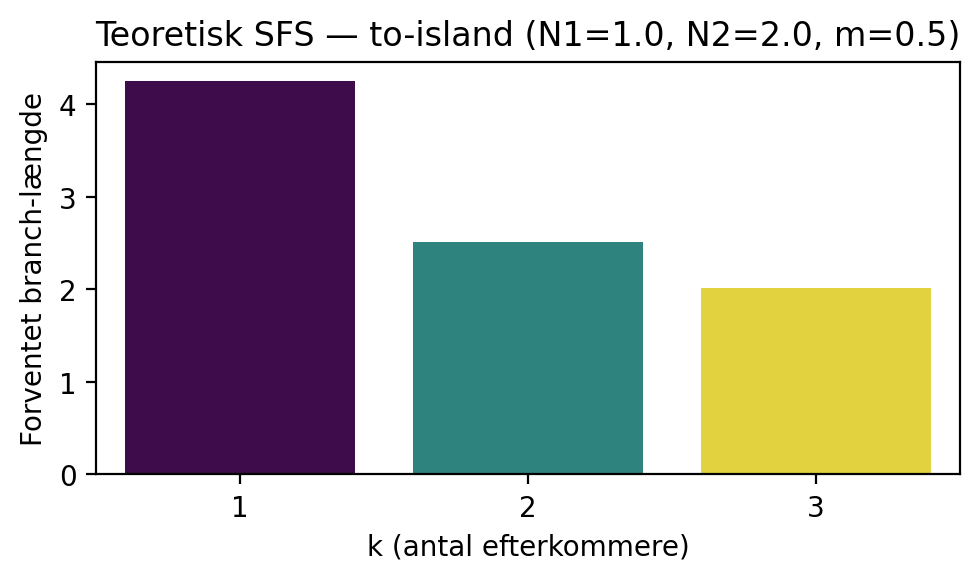

In [12]:
# Beregn forventet SFS ved reward-transform
# Rewarden tæller tid tilbragt med en lineage der har præcis i efterkommere
state_mat = graph_2i.states()
descendants_rewards = []
for k_val in range(1, nr_samples):
    r = np.zeros(state_mat.shape[0])
    for row_idx in range(state_mat.shape[0]):
        for col_idx in range(indexer.state_length):
            props = indexer.lineages.index_to_props(col_idx)
            if props.descendants == k_val:
                r[row_idx] += state_mat[row_idx, col_idx]
    descendants_rewards.append(r)

sfs = np.array([graph_2i.expectation(rewards=r) for r in descendants_rewards])
x = np.arange(1, nr_samples)

fig, ax = plt.subplots(figsize=(5, 3))
sns.barplot(x=x, y=sfs, hue=x, width=0.8, palette="viridis", legend=False, ax=ax)
ax.set_xlabel("k (antal efterkommere)")
ax.set_ylabel("Forventet branch-længde")
ax.set_title(f"Teoretisk SFS — to-island (N1={N1_true}, N2={N2_true}, m={m_true})")
plt.tight_layout()
plt.show()

## Joint probability graf — diskrete mutations-observationer

For at kunne fitte modellen til rigtige SNP-data laver jeg en joint probability graf, der kobler coalescent-modellen til en Poisson-mutations-proces.

Hver observation er et tupel $(k_1,k_2,...,k_{n-1})$ som fortæller hvor mange singletons, doubletons osv. en lokus-konfiguration har. Mutationsraten indgår som en ekstra parameter.

In [13]:
mutation_rate = 1.0   # i coalescent-enheder — svarer til theta = 4*N*mu*L
joint_graph = graph_2i.joint_prob_graph(
    indexer,
    reward_only=["descendants"],
    reward_limit=1,
    tot_reward_limit=1000,
    mutation_rate=mutation_rate,
)

true_theta_joint = [1/N1_true, 1/N2_true, m_true, mutation_rate]
joint_graph.update_weights(true_theta_joint)

tbl = joint_graph.joint_prob_table()
print(f"Antal unikke observation-mønstre: {len(tbl)}")
print(f"Deficit (afkortnings-bias): {(1 - tbl['prob'].sum()).item():.4f}")
tbl.head(10)

Antal unikke observation-mønstre: 8
Deficit (afkortnings-bias): 0.8174


,descendants_1,descendants_2,descendants_3,descendants_4,prob
t_vertex_index,,,,,
97,0,0,0,0,0.058421
98,0,1,0,0,0.020558
99,1,0,0,0,0.050526
100,0,0,1,0,0.012195
101,1,0,1,0,0.016778
102,1,1,0,0,0.018763
103,0,1,1,0,0.001932
104,1,1,1,0,0.003472


## Simuler testdata med msprime
Før jeg bruger bavian-data, laver jeg simuleret data med kendte parametre. Dette er den bedste måde at verificere, at min inferens er troværdig.

In [3]:
import msprime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'retina'

def derived_counts(ts, rec_rate):
    records = []
    for var in ts.variants():
        p, g = var.site.position, var.genotypes
        records.append((int(p), p*rec_rate, g.sum()))
    df = pd.DataFrame().from_records(
        records, columns=["pos", "gen_pos", "count"]
        )
    return df

mut_rate = 5e-10
rec_rate = 1e-8
nr_samples = 5
seq_length = 100_000_000
pop1_size, pop2_size, anc_pop_size = 20_000, 10_000, 15_000
migr_pop1_to_pop2 = 1e-4
migr_pop2_to_pop1 = 5e-4

demography_sym = msprime.Demography()
demography_sym.add_population(name="pop1", initial_size=pop1_size)
demography_sym.add_population(name="pop2", initial_size=pop2_size)
# Symmetrisk migration — samme rate begge veje
sym_rate = (migr_pop1_to_pop2 + migr_pop2_to_pop1) / 2
demography_sym.set_migration_rate(source="pop1", dest="pop2", rate=sym_rate)
demography_sym.set_migration_rate(source="pop2", dest="pop1", rate=sym_rate)

ts_sym = msprime.sim_ancestry(
    samples={"pop1": nr_samples, "pop2": 0},
    ploidy=1,
    demography=demography_sym,
    recombination_rate=rec_rate,
    sequence_length=seq_length,
    random_seed=42
)
ts_sym = msprime.sim_mutations(ts_sym, rate=mut_rate, random_seed=42)
df_sym = derived_counts(ts_sym, rec_rate)
df_sym.to_csv("island_model_derived_counts.csv", index=False)

print(f"Symmetrisk simulering: {len(df_sym)} SNPs")

Symmetrisk simulering: 5841 SNPs


In [4]:
def pairs_in_range(nums, diff_lo, diff_hi):
    n = len(nums)
    lo, hi = 1, 1
    pairs = []
    for i in range(n):
        if lo <= i:
            lo = i + 1
        while lo < n and nums[lo] - nums[i] < diff_lo:
            lo += 1
        if hi <= i:
            hi = i + 1
        while hi < n and nums[hi] - nums[i] <= diff_hi:
            hi += 1
        for j in range(lo, hi):
            pairs.append((i, j))
    return pairs

df_sym = pd.read_csv("island_model_derived_counts.csv")

col = "pos" # can also use "gen_pos"
distance, tolerance = 5000, 500
min_dist, max_dist = distance - tolerance, distance + tolerance
records = []
for i, j in pairs_in_range(df_sym[col].values, min_dist, max_dist):
    records.append((df_sym.at[i, col], df_sym.at[j, col], df_sym.at[i, "count"], df_sym.at[j, "count"]))
pairs = pd.DataFrame.from_records(records, columns=["pos1", "pos2", "count1", "count2"])
pairs.head()

,pos1,pos2,count1,count2
0,210251,214800,1,1
1,389609,394959,2,2
2,394959,400407,2,4
3,679579,684244,1,1
4,1275547,1280364,4,1


In [5]:
mask = (pairs.pos1 == pairs.pos1.shift()) | (pairs.pos2 == pairs.pos2.shift())
filtered_pairs = pairs.loc[~mask, :]
filtered_pairs.head()

,pos1,pos2,count1,count2
0,210251,214800,1,1
1,389609,394959,2,2
2,394959,400407,2,4
3,679579,684244,1,1
4,1275547,1280364,4,1


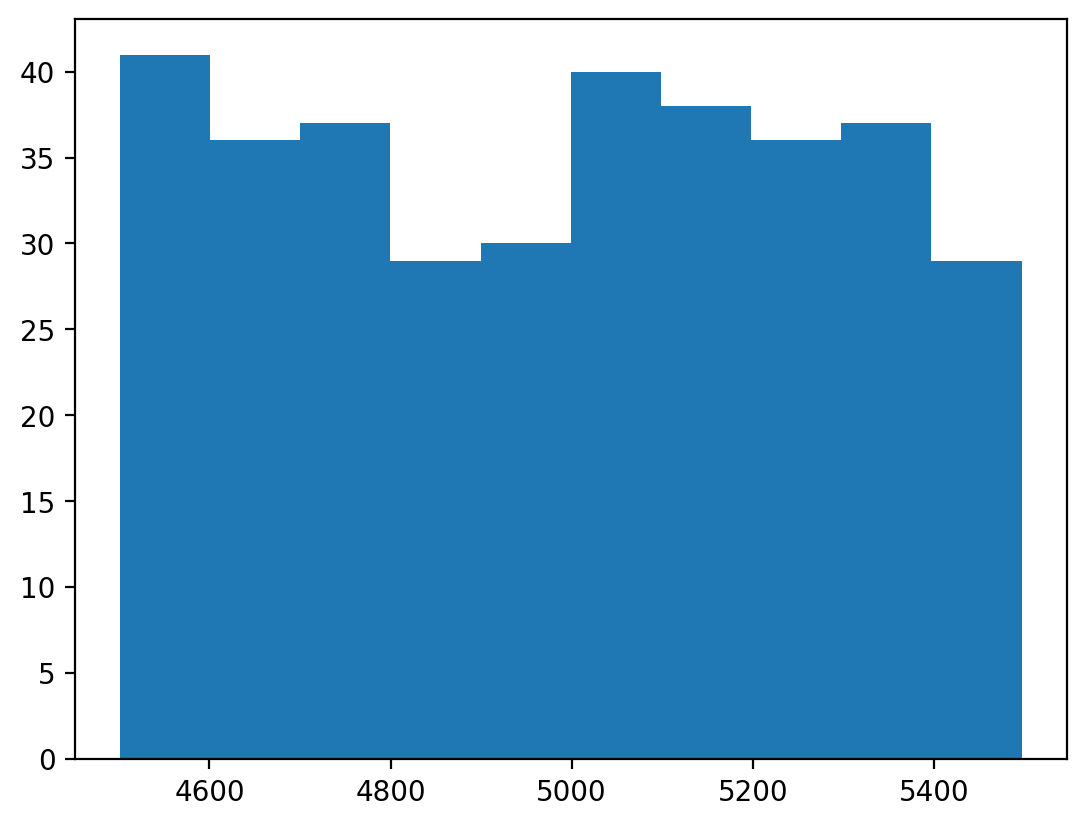

In [6]:
plt.hist(filtered_pairs.pos2 - filtered_pairs.pos1, bins=10) ;

In [7]:
n = len(filtered_pairs)
observations = np.zeros((n, nr_samples), dtype=int)
observations
for i, pair in enumerate(filtered_pairs[["count1", "count2"]].values):
    observations[i, pair] = 1

In [8]:
msg = f"""
Two-locus observations across {nr_samples} samples of {seq_length/1e6:.0f} Mb:
    Mutation rate:
        {mut_rate} events/site/generation
    Recombination rate:
        {rec_rate} crossovers/base/generation
    Haploid population sizes:
        pop1: {pop1_size}
        pop2: {pop2_size}
    Migration rate:
        pop1 -> pop2: {migr_pop1_to_pop2}
        pop2 -> pop1: {migr_pop2_to_pop1}
"""
print(msg)


Two-locus observations across 5 samples of 100 Mb:
    Mutation rate:
        5e-10 events/site/generation
    Recombination rate:
        1e-08 crossovers/base/generation
    Haploid population sizes:
        pop1: 20000
        pop2: 10000
    Migration rate:
        pop1 -> pop2: 0.0001
        pop2 -> pop1: 0.0005



## Validering: genfind sande parametre fra msprime-simulering

Inden jeg bruger bavian-data skal jeg verificere, at inferensmetoden er troværdig.

In [14]:
# Konverter msprime-observationer til joint-probability format
feature_cols_sim = [c for c in tbl.columns if c.startswith("descendants")]
allowed_sim = set(tuple(int(x) for x in r) for r in tbl[feature_cols_sim].values)

obs_sim_2i = []
for k in df_sym["count"].values:
    k = int(k)
    if k <= 0 or k >= nr_samples:
        continue
    o = [0] * len(feature_cols_sim)
    if 0 < k - 1 < len(o):
        o[k - 1] = 1
    if tuple(o) in allowed_sim:
        obs_sim_2i.append(o)

print(f"Simulerede observationer til inferens: {len(obs_sim_2i):,}")

# Tjek defekt på disse observationer
tbl_check = joint_graph.joint_prob_table()
defect = 1 - tbl_check['prob'].sum()
print(f"Defekt (joint probability tabel): {defect.item():.4f}")
if defect > 0.05:
    print("  ⚠ Defekt er høj — overvej at øge tot_reward_limit")
else:
    print("  ✓ Defekt er acceptabel")

Simulerede observationer til inferens: 5,080
Defekt (joint probability tabel): 0.8174
  ⚠ Defekt er høj — overvej at øge tot_reward_limit


In [ ]:
# Kør probability_matching som prior til SVGD
pm_sim = joint_graph.probability_matching(
    obs_sim_2i[:3000],
    fixed=[(3, mutation_rate)],
)
print(f"PM estimat (sand theta = {true_theta_joint[:3]}): {pm_sim.theta[:3]}")

# SVGD validering
rng_val = np.random.default_rng(99)
obs_val = obs_sim_2i
if len(obs_val) > 5000:
    idx_val = rng_val.choice(len(obs_val), 5000, replace=False)
    obs_val = [obs_val[i] for i in idx_val]

svgd_sim_2i = joint_graph.svgd(
    observed_data=obs_val,
    fixed=[(3, mutation_rate)],
    n_iterations=150,
    n_particles=80,
    prior=pm_sim.prior,
    learning_rate=ExpStepSize(first_step=0.08, last_step=0.01, tau=40.0),
)

print("\nValidering: genfinder vi sande parametre fra simulerede data?")
print(f"Sande parametre: N1={N1_true}, N2={N2_true}, m={m_true}")
svgd_sim_2i.summary(ci_method="hpd", ci_level=0.95)
svgd_sim_2i.plot_ci(ci_method="hpd", true_theta=true_theta_joint)
plt.suptitle("Validering: posterior CI vs. sande parametre (msprime-simulering)")
plt.show()
svgd_sim_2i.plot_convergence()

## Anvend modellen på bavian-data

Jeg indlæser de gemte derived-count-filer fra notebook 02 og fitter to-island modellen på yellow baboon data. Modellen antager at alle samples er trukket fra en population og at den anden population kun bidrager via migration.

In [ ]:
def load_baboon_ktons(path, n_samples_use, seed=0):
    p = Path(path)
    if not p.exists():
        print(f"[advarsel] {p} findes ikke — kør notebook 03 først.")
        return None
    df = pd.read_csv(p)
    df = df[df["nr_samples"] >= n_samples_use].copy()
    if len(df) == 0:
        print(f"[advarsel] {p} har ingen varianter med nr_samples >= {n_samples_use}")
        return None
    rng = np.random.default_rng(seed)
    k = rng.hypergeometric(
        ngood=df["derived_count"].values,
        nbad=(df["nr_samples"] - df["derived_count"]).values,
        nsample=n_samples_use,
    )
    k = k[(k > 0) & (k < n_samples_use)]
    return k

k_east = load_baboon_ktons(OUT_DIR / "derived_counts_P_cynocephalus.csv", nr_samples)

if k_east is not None:
    print(f"Antal segregerende SNPs efter subsampling (n={nr_samples}): {len(k_east):,}")

    feature_cols = [c for c in tbl.columns if c.startswith("descendants")]
    allowed = set(tuple(int(x) for x in r) for r in tbl[feature_cols].values)
    obs_baboon = []
    for k in k_east:
        o = [0] * len(feature_cols)
        if 0 < k - 1 < len(o):
            o[k - 1] = 1
        if tuple(o) in allowed:
            obs_baboon.append(o)
    print(f"Heraf brugbare under model: {len(obs_baboon):,}")

In [ ]:
if k_east is not None and len(obs_baboon) > 1000:
    rng = np.random.default_rng(1)
    if len(obs_baboon) > 5000:
        idx = rng.choice(len(obs_baboon), 5000, replace=False)
        obs_baboon_use = [obs_baboon[i] for i in idx]
    else:
        obs_baboon_use = obs_baboon

    svgd_baboon = joint_graph.svgd(
        observed_data=obs_baboon_use,
        fixed=[(3, mutation_rate)],
        n_iterations=150,
        n_particles=80,
        prior=[
            GaussPrior(ci=[0.1, 5.0]),
            GaussPrior(ci=[0.1, 5.0]),
            GaussPrior(ci=[0.0, 3.0]),
            None,
        ],
        learning_rate=ExpStepSize(first_step=0.08, last_step=0.01, tau=40.0),
    )
    svgd_baboon.summary(ci_method="hpd", ci_level=0.95)

## Parameterkonvertering med tabel

In [ ]:
# Konverter posterior-estimater til biologiske enheder
pi_df = pd.read_csv(OUT_DIR / "pi_per_population.csv", index_col=0)
pi_yellow = pi_df.loc["Yellow baboon", "pi"]
Ne_ref = pi_yellow / (4 * MUT_RATE)

print(f"pi (Yellow baboon):    {pi_yellow:.6f}")
print(f"N_ref = pi/(4*mu):      {Ne_ref:,.0f} individer")
print()

res = svgd_baboon.get_results()
theta = res['theta_mean']

N1 = (1 / theta[0]) * Ne_ref
N2 = (1 / theta[1]) * Ne_ref
m_gen = theta[2] / (2 * Ne_ref)

results_table = pd.DataFrame({
    'Parameter': ['N1 (Yellow baboon)', 'N2 (Kinda)', 'Migration (m)'],
    'Coalescent-enheder': [f'{theta[0]:.4f}', f'{theta[1]:.4f}', f'{theta[2]:.4f}'],
    'Biologiske enheder': [f'{N1:,.0f} individer', f'{N2:,.0f} individer', f'{m_gen:.2e} /generation'],
})
print(results_table.to_string(index=False))

In [ ]:
if k_east is not None and len(obs_baboon) > 1000:
    svgd_baboon.plot_ci(ci_method="hpd")
    plt.suptitle("Posterior CI — Yellow baboon")
    plt.show()

In [ ]:
svgd_baboon.plot_convergence();

In [ ]:
if k_east is not None and len(obs_baboon) > 1000:
    svgd_baboon.plot_hdr()
    plt.suptitle("Posterior HDR — Yellow baboon (Two-island)")
    plt.show()

In [ ]:
if k_east is not None and len(obs_baboon) > 1000:
    svgd_baboon.plot_hdr(hexgrid=False)
    plt.suptitle("Posterior HDR (scatter) — Yellow baboon (Two-island)")
    plt.show()

In [ ]:
if k_east is not None and len(obs_baboon) > 1000:
    svgd_baboon.plot_pairwise(true_theta=true_theta)
    plt.suptitle("Posterior pairwise — Yellow baboon", y=1.02)
    plt.show()

## Samlet resultater 

In [ ]:
pi_file = OUT_DIR / "pi_per_population.csv"
if pi_file.exists():
    pi_df = pd.read_csv(pi_file, index_col=0)
    if "Yellow baboon" in pi_df.index:
        pi_east = pi_df.loc["Yellow baboon", "pi"]
        Ne_ref = pi_east / (4 * MUT_RATE)
        print(f"pi (Yellow baboon):  {pi_east:.6f}")
        print(f"Implied Ne_ref:       {Ne_ref:,.0f}")
        if "svgd_baboon" in dir():
            res = svgd_baboon.get_results()
            theta_mean = res["theta_mean"]
            N1_est = (1 / theta_mean[0]) * Ne_ref
            N2_est = (1 / theta_mean[1]) * Ne_ref
            m_est_gen = theta_mean[2] / (2 * Ne_ref)
            print("\nEstimater (posterior mean):")
            print(f"  N1 (Yellow baboon):  {N1_est:,.0f}")
            print(f"  N2 (Kinda-lignende):  {N2_est:,.0f}")
            print(f"  Migration rate:       {m_est_gen:.2e} / generation")

## Posterior predictive check - SFS

En god model kan reproducere de observerede data. Jeg sammenligner her det observerede folded SFS (fra notebook 03) med det model-forudsagte SFS under de estimerede parametre.

Ideen: sæt posterior mean-parametrene ind i grafen og beregn forventet SFS via reward-transforms. Matcher det med det observerede SFS, er modellen troværdig. Systematiske afvigelser (fx model underestimerer singletons) indikerer, at modellen er forkert specificeret.

In [ ]:
sfs_obs_path = OUT_DIR / "sfs_folded_P_cynocephalus.csv"
if sfs_obs_path.exists() and "svgd_baboon" in dir():
    # Indlæs observeret foldet SFS
    sfs_obs = pd.read_csv(sfs_obs_path, index_col=0).squeeze()
    n_obs_total = sfs_obs.sum()

    # Sæt posterior mean-parametre i grafen
    res = svgd_baboon.get_results()
    graph_2i.update_weights(res["theta_mean"][:graph_2i.param_length()])

    # Beregn forventet SFS fra modellen via reward-transforms
    # Reward[k-1] = tid brugt med en linje der har præcis k efterkommere
    state_mat = graph_2i.states()
    sfs_model = []
    for k_val in range(1, nr_samples):
        r = np.zeros(state_mat.shape[0])
        for row_idx in range(state_mat.shape[0]):
            for col_idx in range(indexer.state_length):
                props = indexer.lineages.index_to_props(col_idx)
                if props.descendants == k_val:
                    r[row_idx] += state_mat[row_idx, col_idx]
        sfs_model.append(graph_2i.expectation(rewards=r))

    # Fold det model-forudsagte SFS (summer symmetriske bins)
    sfs_model = np.array(sfs_model)
    mid = nr_samples // 2
    sfs_model_folded = sfs_model.copy().astype(float)
    for i in range(1, mid):
        sfs_model_folded[i - 1] = sfs_model[i - 1] + sfs_model[nr_samples - i - 1]
    sfs_model_folded = sfs_model_folded[:mid]

    # Normaliser begge til at summere til 1 (sammenlign form)
    sfs_obs_norm   = sfs_obs.values[:mid] / sfs_obs.values[:mid].sum()
    sfs_model_norm = sfs_model_folded / sfs_model_folded.sum()

    x = np.arange(1, mid + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.5))

    # Sammenligning af normaliserede SFS
    ax1.bar(x - 0.2, sfs_obs_norm,   width=0.4, label="Observeret", color="C0", alpha=0.8)
    ax1.bar(x + 0.2, sfs_model_norm, width=0.4, label="Model (to-ø)", color="C1", alpha=0.8)
    ax1.set_xlabel("Minor allele count (k)")
    ax1.set_ylabel("Normaliseret frekvens")
    ax1.set_title("Posterior predictive check — SFS\nYellow baboon")
    ax1.legend()

    # Residualplot: (observeret − model) / observeret
    residuals = (sfs_obs_norm - sfs_model_norm) / (sfs_obs_norm + 1e-12)
    ax2.bar(x, residuals, color=np.where(residuals > 0, "C0", "C1"), alpha=0.8)
    ax2.axhline(0, color="black", lw=0.8)
    ax2.set_xlabel("Minor allele count (k)")
    ax2.set_ylabel("(Obs − Model) / Obs")
    ax2.set_title("Relativ afvigelse")

    plt.tight_layout()
    plt.show()

    # Kvantificér fit med chi-squared goodness-of-fit test
    obs_counts   = sfs_obs.values[:mid]
    exp_counts   = sfs_model_norm * obs_counts.sum()
    chi2_stat    = np.sum((obs_counts - exp_counts)**2 / (exp_counts + 1))
    print(f"Chi²-statistic: {chi2_stat:.1f}  (df={mid-1})")
    print(f"Normaliseret (chi²/df): {chi2_stat/(mid-1):.2f}  — tæt på 1 = godt fit")
else:
    print("Kør notebook 03 og SVGD-inferensen ovenfor først.")

## Fler-population Inferens: Parvise analyser

I denne notebook udvider jeg to-island-modellen til alle relevante par af bavianpopulationer. Målet er at kortlægge: - Migrationsrater mellem populationspar (heatmap) - Effektiv populationsstørrelse for hvert par - Relative TMRCA som mål for genetisk afstand

In [ ]:
def load_ktons(path, n_use=2000, seed=42):
    """Indlæs k-ton data fra CSV og subsample til n_use observationer."""
    p = Path(path)
    if not p.exists():
        print(f"ADVARSEL: {p} ikke fundet – kør notebook 03 først.")
        return None
    df = pd.read_csv(p)
    rng = np.random.default_rng(seed)
    if len(df) > n_use:
        df = df.sample(n_use, random_state=rng.integers(1e6))
    return df

populations = {
    "P_cynocephalus": "Yellow Baboon",
    "P_kindae": "Kinda",
    "P_anubis": "Olive baboon",
    "P_papio": "Guinea baboon",
    "P_ursinus": "Chacma baboon",
    "P_hamadryas": "Hamadryas baboon",
}

data_files = {
    "P_cynocephalus": OUT_DIR / "derived_counts_P_cynocephalus.csv",
    "P_kindae": OUT_DIR / "derived_counts_P_kindae.csv",
    "P_anubis": OUT_DIR / "derived_counts_P_anubis.csv",
    "P_papio": OUT_DIR / "derived_counts_P_papio.csv",
    "P_ursinus": OUT_DIR / "derived_counts_P_ursinus.csv",
    "P_hamadryas": OUT_DIR / "derived_counts_P_hamadryas.csv",
}

dfs = {k: load_ktons(v) for k, v in data_files.items()}
for k, df in dfs.items():
    if df is not None:
        print(f"{k:3s} ({populations[k]:30s}): {len(df):6,d} SNPs")

## To-island-model for parvise analyser

In [ ]:
def build_two_island_joint(n_samples_pop1, n_samples_pop2, mutation_rate):
    """
    Byg joint_prob_graph for to-island-modellen med n1 samples fra pop1 og n2 fra pop2.
    Returnerer (joint_graph, indexer, n_params).
    """
    nr1 = n_samples_pop1
    nr2 = n_samples_pop2

    indexer = StateIndexer(
        lineages=[
            Property("descendants", min_value=1, max_value=max(nr1, nr2)),
            Property("in_pop", min_value=1, max_value=2),
        ]
    )

    @with_ipv([nr1, nr2] + [0] * (nr1 + nr2 - 2))
    def two_island(state):
        desc = state[0::2]   # descendants per lineage
        ipop = state[1::2]   # population per lineage
        k1 = sum(1 for d, p in zip(desc, ipop) if d > 0 and p == 1)
        k2 = sum(1 for d, p in zip(desc, ipop) if d > 0 and p == 2)
        transitions = []

        # Coalescens i pop 1 (rate = C(k1,2) * 1/N1)
        if k1 >= 2:
            for i in range(len(desc)):
                if desc[i] > 0 and ipop[i] == 1:
                    for j in range(i+1, len(desc)):
                        if desc[j] > 0 and ipop[j] == 1:
                            new_state = list(state)
                            new_state[2*i]   += desc[j]
                            new_state[2*j]    = 0
                            new_state[2*j+1]  = 0
                            transitions.append((
                                np.array(new_state),
                                0.0,
                                [1.0, 0.0, 0.0]  # rate: 1/N1
                            ))

        # Coalescens i pop 2 (rate = C(k2,2) * 1/N2)
        if k2 >= 2:
            for i in range(len(desc)):
                if desc[i] > 0 and ipop[i] == 2:
                    for j in range(i+1, len(desc)):
                        if desc[j] > 0 and ipop[j] == 2:
                            new_state = list(state)
                            new_state[2*i]   += desc[j]
                            new_state[2*j]    = 0
                            new_state[2*j+1]  = 0
                            transitions.append((
                                np.array(new_state),
                                0.0,
                                [0.0, 1.0, 0.0]  # rate: 1/N2
                            ))

        # Migration pop1 → pop2 og pop2 → pop1 (rate = k * m)
        for i in range(len(desc)):
            if desc[i] > 0:
                new_state = list(state)
                new_pop = 2 if ipop[i] == 1 else 1
                new_state[2*i+1] = new_pop
                transitions.append((
                    np.array(new_state),
                    0.0,
                    [0.0, 0.0, 1.0]  # rate: m
                ))

        return transitions

    graph_2i = Graph(
        state_length=indexer.state_length(),
        callback=two_island,
        parameterized=True,
        nr_samples=nr1 + nr2,
    )

    n_coal_params = 3  # 1/N1, 1/N2, m
    joint_2i = graph_2i.joint_prob_graph(
        indexer, reward_only=["descendants"],
        reward_limit=max(nr1, nr2)
    )
    return joint_2i, indexer, n_coal_params, mutation_rate

print("two-island builder klar")

### Kør to-island-model på alle populationspar

Jeg analyserer 15 par fra de 6 populationer. For hvert par: 

1. Byg to-island joint_prob_graph 
2. Kør method-of-moments for startværdier 
3. Kør SVGD for fuld posterior 
4. Gem resultater

In [ ]:
# Definer par der skal analyseres
pairs = [
    ("P_cynocephalus", "P_kindae"),   # Yellow × Kinda
    ("P_cynocephalus", "P_anubis"),   # Yellow × Olive
    ("P_cynocephalus", "P_papio"),   # Yellow × Guinea
    ("P_cynocephalus", "P_ursinus"),   # Yellow × Chacma
    ("P_cynocephalus", "P_hamadryas"),  # Yellow × Hamadryas
    ("P_kindae", "P_anubis"),   # Kinda × Olive
    ("P_kindae", "P_papio"),   # Kinda × Guinea
    ("P_kindae", "P_ursinus"),   # Kinda × Chacma
    ("P_kindae", "P_hamadryas"), # Kinda × Hamadryas
    ("P_anubis", "P_papio"),  # Olive × Guinea
    ("P_anubis", "P_ursinus"), # Olive × Chacma
    ("P_anubis", "P_hamadryas"), # Olive × Hamadryas
    ("P_papio", "P_ursinus"), # Guinea × Chacma
    ("P_papio", "P_hamadryas"), # Gunia × Hamadryas
    ("P_ursinus", "P_hamadryas"), # Chacma × Hamadryas
]

N_SVGD    = 50     # partikler (reducer for hurtig test)
N_ITER    = 300    # iterationer
N_USE     = 1000   # SNPs per population
MU        = MUT_RATE

results_pairs = {}

for (p1, p2) in pairs:
    name = f"{p1}_{p2}"
    print(f"\n{'='*50}")
    print(f"Analyserer par: {populations[p1]} × {populations[p2]}")
    
    df1 = dfs.get(p1)
    df2 = dfs.get(p2)
    if df1 is None or df2 is None:
        print("  SKIP: data mangler")
        continue
    
    # Subsample
    rng = np.random.default_rng(42)
    d1 = df1.sample(min(N_USE, len(df1)), random_state=42)
    d2 = df2.sample(min(N_USE, len(df2)), random_state=42)
    n1 = int(d1["nr_samples"].max())
    n2 = int(d2["nr_samples"].max())
    
    # Byg k-ton observationer for joint_prob
    # For to-island-model: obs = array af (k1, k2) par
    # Her bruger jeg kun within-pop SFS (diagonal)
    obs1 = d1[["derived_count", "nr_samples"]].values.astype(int)
    obs2 = d2[["derived_count", "nr_samples"]].values.astype(int)
    
    # Kombiner: brug en subsample af begge
    k1_vals = obs1[:, 0]
    k2_vals = obs2[:min(len(obs2), len(obs1)), 0]
    min_len = min(len(k1_vals), len(k2_vals))
    
    # To-island observations: array af k-ton fra begge populationer
    obs_joint = np.column_stack([k1_vals[:min_len], k2_vals[:min_len]])
    
    try:
        joint_2i, indexer_2i, n_coal, mu = build_two_island_joint(n1, n2, MU)
        
        # Startpunkt via MoM
        mut_idx = joint_2i.param_length() - 1
        fixed_params = [(mut_idx, MU)]
        
        theta_init = np.array([1e-4, 1e-4, 1e-5])
        
        svgd = joint_2i.svgd(
            observed_data=obs_joint,
            theta_dim=n_coal,
            n_particles=N_SVGD,
            n_iterations=N_ITER,
            fixed=fixed_params,
            step_size=0.01,
        )
        
        theta_post = svgd.particles  # shape (N_SVGD, n_coal)
        theta_mean = theta_post.mean(axis=0)
        theta_std  = theta_post.std(axis=0)
        
        results_pairs[name] = {
            "pop1": p1, "pop2": p2,
            "theta_mean": theta_mean,
            "theta_std":  theta_std,
            "particles":  theta_post,
            "n1": n1, "n2": n2,
        }
        print(f"  theta_mean = {theta_mean}")
        
    except Exception as e:
        print(f"  FEJL: {e}")
        results_pairs[name] = None

print("\nAlle par analyseret.")

### Konverter til biologiske parametre

Jeg konverterer coalescent-parametre til biologisk fortolkbare størrelser.

- N_e = 1 / (2 × θ_coal) — effektiv populationsstørrelse (diploid)
- m = migrationsrate (per generation per individ)
- T_split estimeres fra ancestral Ne via epoch-model (beregnes i NB06)

In [ ]:
def theta_to_biology(theta_mean, theta_std=None):
    """Konverter [1/N1, 1/N2, m] til biologisk fortolkbare størrelser."""
    inv_N1, inv_N2, m = theta_mean
    Ne1 = 1.0 / (2 * inv_N1) if inv_N1 > 0 else np.nan
    Ne2 = 1.0 / (2 * inv_N2) if inv_N2 > 0 else np.nan
    
    result = {
        "Ne1": Ne1,
        "Ne2": Ne2,
        "m":   m,
        "Nem": Ne1 * m if not np.isnan(Ne1) else np.nan,  # Nem = effektiv migration
    }
    if theta_std is not None:
        inv_N1_s, inv_N2_s, m_s = theta_std
        result["Ne1_std"] = Ne1**2 * inv_N1_s if not np.isnan(Ne1) else np.nan
        result["Ne2_std"] = Ne2**2 * inv_N2_s if not np.isnan(Ne2) else np.nan
        result["m_std"]   = m_s
    return result

# Byg resultatstabel
rows = []
for name, res in results_pairs.items():
    if res is None:
        continue
    bio = theta_to_biology(res["theta_mean"], res["theta_std"])
    rows.append({
        "Par": name,
        "Pop1": populations[res["pop1"]],
        "Pop2": populations[res["pop2"]],
        "Ne_pop1": f"{bio['Ne1']:.0f}",
        "Ne_pop2": f"{bio['Ne2']:.0f}",
        "m (per gen)": f"{bio['m']:.2e}",
        "Nem": f"{bio['Nem']:.2f}",
    })

results_df = pd.DataFrame(rows)
print(results_df.to_string(index=False))

## Migrationsrate heatmap
Heatmapvet viser migrationsraten m mellem hvert populationspar. Høj Nem (> 1) indikerer substantiel genudveksling.

In [ ]:
pop_order = ["P_cynocephalus", "P_kindae", "P_anubis", "P_papio", "P_ursinus", "P_hamadryas"]
pop_labels = {
    "P_cynocephalus": "Yellow Baboon",
    "P_kindae": "Kinda",
    "P_anubis": "Olive baboon",
    "P_papio": "Guinea baboon",
    "P_ursinus": "Chacma baboon",
    "P_hamadryas": "Hamadryas baboon",
    "og": "Olive gog",
}

n_pops = len(pop_order)
m_matrix  = np.full((n_pops, n_pops), np.nan)
Ne_matrix = np.full((n_pops, n_pops), np.nan)

for name, res in results_pairs.items():
    if res is None:
        continue
    i = pop_order.index(res["pop1"])
    j = pop_order.index(res["pop2"])
    bio = theta_to_biology(res["theta_mean"])
    m_matrix[i, j] = bio["m"]
    m_matrix[j, i] = bio["m"]   # symmetrisk model
    Ne_matrix[i, j] = (bio["Ne1"] + bio["Ne2"]) / 2
    Ne_matrix[j, i] = Ne_matrix[i, j]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

labels = [pop_labels[p] for p in pop_order]

# Heatmap 1: migrationsrate m
im1 = axes[0].imshow(m_matrix, cmap="YlOrRd", aspect="auto",)
axes[0].set_xticks(range(n_pops)); axes[0].set_xticklabels(labels, fontsize=8)
axes[0].set_yticks(range(n_pops)); axes[0].set_yticklabels(labels, fontsize=8)
axes[0].set_title("Migrationsrate m (per generation)", fontsize=11)
plt.colorbar(im1, ax=axes[0])

for i in range(n_pops):
    for j in range(n_pops):
        if not np.isnan(m_matrix[i, j]):
            axes[0].text(j, i, f"{m_matrix[i,j]:.1e}", ha="center", va="center",
                         fontsize=7, color="black")

# Heatmap 2: Nem (effektiv migration)
Nem_matrix = Ne_matrix * m_matrix
im2 = axes[1].imshow(Nem_matrix, cmap="Blues", aspect="auto")
axes[1].set_xticks(range(n_pops)); axes[1].set_xticklabels(labels, fontsize=8)
axes[1].set_yticks(range(n_pops)); axes[1].set_yticklabels(labels, fontsize=8)
axes[1].set_title("Effektiv migration N·m", fontsize=11)
plt.colorbar(im2, ax=axes[1])

for i in range(n_pops):
    for j in range(n_pops):
        if not np.isnan(Nem_matrix[i, j]):
            axes[1].text(j, i, f"{Nem_matrix[i,j]:.2f}", ha="center", va="center",
                         fontsize=7, color="black")

plt.tight_layout()
plt.show()

## Genetisk afstandsmatrix
Som supplement til migrationsraten beregner jeg den forventede parvise TMRCA. Under to-ø-modellen er den forventede TMRCA (i coalescent-enheder):

$$E[T_{MRCA}] \approx \frac{1}{\theta_1} + \frac{1}{\theta_2} + \frac{1}{m}$$

(approksimativt, for svag migration)

Jeg omsætter til år: $T_{years} = T_{coal} \times 2N_{ref} \times GEN_{TIME}$

In [ ]:
# Beregn parvise TMRCA (approksimativt)
Ne_ref = 50_000  # reference Ne i individer

tmrca_matrix = np.full((n_pops, n_pops), np.nan)

for name, res in results_pairs.items():
    if res is None:
        continue
    i = pop_order.index(res["pop1"])
    j = pop_order.index(res["pop2"])
    inv_N1, inv_N2, m = res["theta_mean"]
    # E[T_MRCA] i coalescent-enheder: 1/N1 + 1/N2 + 1/(2m) (approx.)
    if m > 0:
        T_coal = 1/inv_N1 + 1/inv_N2 + 1/(2*m)
    else:
        T_coal = np.nan
    # Konverter til år (T_coal er i enheder af 2N generationer)
    T_years = T_coal * 2 * Ne_ref * GEN_TIME
    tmrca_matrix[i, j] = T_years / 1e6   # i millioner år
    tmrca_matrix[j, i] = tmrca_matrix[i, j]

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(tmrca_matrix, cmap="viridis_r", aspect="auto")
ax.set_xticks(range(n_pops)); ax.set_xticklabels(labels, fontsize=9)
ax.set_yticks(range(n_pops)); ax.set_yticklabels(labels, fontsize=9)
ax.set_title("Forventet parvise TMRCA (millioner år)", fontsize=11)
plt.colorbar(im, ax=ax, label="Ma")

for i in range(n_pops):
    for j in range(n_pops):
        if not np.isnan(tmrca_matrix[i, j]):
            ax.text(j, i, f"{tmrca_matrix[i,j]:.2f}", ha="center", va="center",
                    fontsize=8, color="white")

plt.tight_layout()
plt.show()


# Gem som CSV
tmrca_df = pd.DataFrame(
    tmrca_matrix,
    index=[pop_labels[p].replace("\n", " ") for p in pop_order],
    columns=[pop_labels[p].replace("\n", " ") for p in pop_order]
)

## Posterior-fordelinger for alle par
For hvert par plotter jeg posterior-fordelingen af de tre parametre (1/N₁, 1/N₂, m)

In [ ]:
valid_pairs = [(name, res) for name, res in results_pairs.items() if res is not None]
n_valid = len(valid_pairs)

if n_valid > 0:
    fig, axes = plt.subplots(n_valid, 3, figsize=(12, 3*n_valid))
    if n_valid == 1:
        axes = axes[np.newaxis, :]

    param_names = ["1/N₁ (coalescent)", "1/N₂ (coalescent)", "m (migration)"]

    for row, (name, res) in enumerate(valid_pairs):
        p1_name = populations[res["pop1"]].split("(")[0].strip()
        p2_name = populations[res["pop2"]].split("(")[0].strip()
        particles = res["particles"]
        
        for col in range(3):
            ax = axes[row, col]
            ax.hist(particles[:, col], bins=20, color="steelblue", edgecolor="white", alpha=0.8)
            ax.axvline(particles[:, col].mean(), color="red", linestyle="--", linewidth=1.5,
                       label=f"mean={particles[:,col].mean():.2e}")
            ax.set_xlabel(param_names[col], fontsize=8)
            ax.set_ylabel("Frekvens" if col == 0 else "", fontsize=8)
            if col == 0:
                ax.set_title(f"{p1_name} × {p2_name}", fontsize=9, fontweight="bold")
            ax.legend(fontsize=7)
            ax.tick_params(labelsize=7)

    plt.tight_layout()
    plt.show()